In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
def softmax(x,axis=-1):
    e_x = np.exp(x-np.max(x,axis=axis,keepdims=True))
    return e_x/e_x.sum(axis=axis,keepdims=True)

def scaled_dot_product_attention(Q,K,V):
    d_k = Q.shape[-1]
    scores = Q @ K.T/np.sqrt(d_k)
    weights = softmax(scores)
    output = weights @ V
    return output,weights

np.random.seed(42)

d_k = 4
words = ['The','cat','sleeps']
Q = np.random.randn(3,d_k)
K=np.random.randn(3,d_k)
V = np.random.randn(3,d_k)
output,attention_weights = scaled_dot_product_attention(Q,K,V)

print("Attention Weight Matrix:")
print(f"{'':12s} {'Key: The':>12s} {'Key: cat':>12s} {'Key: sleeps':>12s}")
for i,word in enumerate(words):
    row = " ".join([f"{w:12.4f}" for w in attention_weights[i]])
    print(f"Query: {word:<6s} {row}")

print(f"\nRow sums (should all be 1.0): {attention_weights.sum(axis=-1)}")
print(f"Output shape: {output.shape}")

Attention Weight Matrix:
                 Key: The     Key: cat  Key: sleeps
Query: The          0.3929       0.1682       0.4390
Query: cat          0.2309       0.2834       0.4857
Query: sleeps       0.2255       0.5587       0.2158

Row sums (should all be 1.0): [1. 1. 1.]
Output shape: (3, 4)


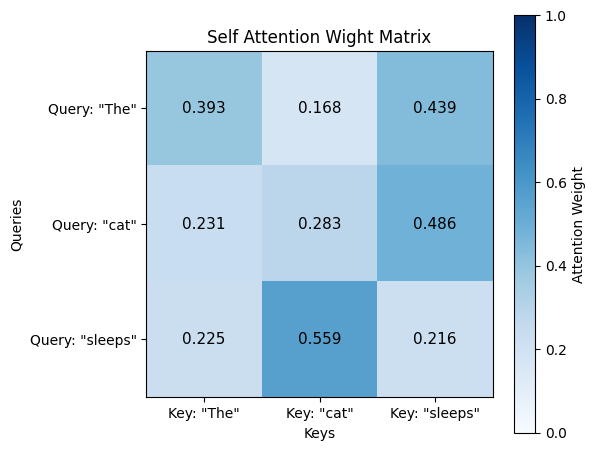

  Highest attention: 'sleeps' attends most strongly to 'cat' (0.559)


In [6]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(6,5))

im = ax.imshow(attention_weights,cmap='Blues',vmin=0,vmax=1)
plt.colorbar(im,ax=ax,label='Attention Weight')

ax.set_xticks(range(len(words)))
ax.set_yticks(range(len(words)))
ax.set_xticklabels([f'Key: "{w}"' for w in  words])
ax.set_yticklabels([f'Query: "{w}"' for w in words])
ax.set_title('Self Attention Wight Matrix')
ax.set_xlabel("Keys")
ax.set_ylabel("Queries")

for i in range(len(words)):
    for j in range(len(words)):
        ax.text(j,i,f"{attention_weights[i,j]:.3f}",ha='center',
               va='center',color='black',fontsize=11)

plt.tight_layout()
plt.show()

max_pair = np.unravel_index(attention_weights.argmax(), attention_weights.shape)
print(f"  Highest attention: '{words[max_pair[0]]}' attends most strongly to '{words[max_pair[1]]}' ({attention_weights[max_pair]:.3f})")

In [9]:
import tensorflow as tf
from tensorflow.keras import layers,Model

def build_attention_classifier(seq_len,d_model,num_heads,d_proj=None):
    inputs = layers.Input(shape=(seq_len,d_model),name="word_embeddings")
    x=inputs
    if d_proj is not None:
        x=layers.Dense(d_proj,use_bias=False,name="input_projection")(x)
        key_dim = d_proj//num_heads

    else:
        key_dim = d_model//num_heads

    x = layers.MultiHeadAttention(num_heads = num_heads,
                                 key_dim=key_dim,name='self_attention')(x,x)
    x = layers.GlobalAveragePooling1D(name='sequence_avg')(x)
    outputs = layers.Dense(1,activation='sigmoid',name='sentiment_output')(x)
    return Model(inputs=inputs,outputs=outputs,name="Attention_Classifier")

SEQ_LEN=59
D_MODEL=250
NUM_HEADS=2

full_model = build_attention_classifier(SEQ_LEN,D_MODEL,NUM_HEADS)
print("---------full Size Attention Classifier---------")
full_model.summary()

---------full Size Attention Classifier---------


2026-09-16 13:51:18.355756: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "Attention_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_embeddings     │ (None, 59, 250)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 59, 250)   │    251,000 │ word_embeddings[… │
│ (MultiHeadAttentio… │                   │            │ word_embeddings[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_avg        │ (None, 250)       │          0 │ self_attention[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │        251 │ sequence_avg[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 251,251 (981.45 KB)

 Trainable params: 251,251 (981.45 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
import pandas as pd
import numpy as np
import tensorflow_hub as hub
import kagglehub
import os


/usr/local/lib/python3.12/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [11]:
path = kagglehub.dataset_download("dineshpiyasamara/sentiment-analysis-dataset")

In [17]:
df = pd.read_csv(r'/kaggle/input/datasets/dineshpiyasamara/sentiment-analysis-dataset/sentiment_analysis.csv')
df.set_index('id',inplace=True)
df.rename(columns={'tweet':'text'},inplace=True)
df.head()

,label,text
id,,
1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
2,0,Finally a transparant silicon case ^^ Thanks t...
3,0,We love this! Would you go? #talk #makememorie...
4,0,I'm wired I know I'm George I was made that wa...
5,1,What amazing service! Apple won't even talk to...


In [18]:
df =df.sample(frac=1,random_state=42).reset_index(drop=True)
model_path = kagglehub.model_download("google/wiki-words/tensorFlow2/250")

In [29]:
embed = hub.load(model_path)
def get_max_length(df):
    return max(len(row.split()) for row in df['text'] if pd.notna(row))

def get_word2vec_enc(texts):
    return [embed(text.split()) for text in texts]

def get_padded_encoded_texts(encoded_texts,max_len):
    padded=[]
    pad=np.zeros((1,250))
    for enc in encoded_texts:
        n_pad = max_len - enc.shape[0]
        for _ in range(n_pad):
            enc = np.concatenate((pad,enc),axis=0)

        padded.append(enc)

    return padded

def preprocess(df,max_len):
    encoded = get_word2vec_enc(df['text'].tolist())
    padded = get_padded_encoded_texts(encoded,max_len)
    return np.array(padded),np.array(df['label'].tolist())

df_tiny = df.head(200).reset_index(drop=True)
max_len = get_max_length(df)
print(f"Max sequence length: {max_len}")
X_tiny,Y_tiny = preprocess(df_tiny,max_len)
print(f"Tiny X shape: {X_tiny.shape}  — (samples, seq_len, embed_dim)")
print(f"Tiny Y shape: {Y_tiny.shape}")


Max sequence length: 55
Tiny X shape: (200, 55, 250)  — (samples, seq_len, embed_dim)
Tiny Y shape: (200,)


In [30]:
tiny_model = build_attention_classifier(seq_len=max_len,
                                       d_model=250,
                                       num_heads=2,
                                       d_proj=16)
print("-----Tiny Illustration Model-------")
tiny_model.summary()

-----Tiny Illustration Model-------


Model: "Attention_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_embeddings     │ (None, 55, 250)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_projection    │ (None, 55, 16)    │      4,000 │ word_embeddings[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 55, 16)    │      1,088 │ input_projection… │
│ (MultiHeadAttentio… │                   │            │ input_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_avg        │ (None, 16)        │          0 │ self_attention[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_output    │ (None, 1)         │         17 │ sequence_avg[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,105 (19.94 KB)

 Trainable params: 5,105 (19.94 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
tiny_model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
print("Starting tiny training run")
tiny_history = tiny_model.fit(X_tiny,Y_tiny,epochs=5,batch_size=16,validation_split=0.2,verbose=1)

Starting tiny training run
Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7375 - loss: 0.6848 - val_accuracy: 0.7000 - val_loss: 0.6784
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7625 - loss: 0.6639 - val_accuracy: 0.7000 - val_loss: 0.6628
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7625 - loss: 0.6407 - val_accuracy: 0.7000 - val_loss: 0.6464
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7625 - loss: 0.6172 - val_accuracy: 0.7000 - val_loss: 0.6292
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7625 - loss: 0.5902 - val_accuracy: 0.7000 - val_loss: 0.6129


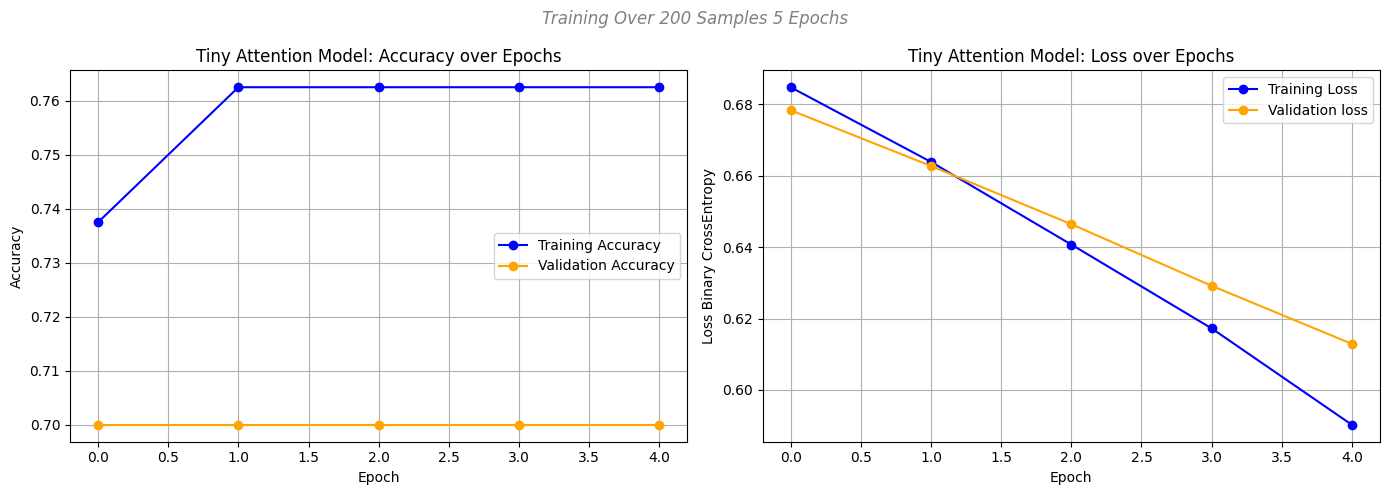


Key observation: the training loss decreased — self-attention trains successfully!
Final training loss:   0.5902
Final training accuracy: 0.7625


In [34]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(tiny_history.history['accuracy'],label='Training Accuracy',color='blue',marker='o')
ax1.plot(tiny_history.history['val_accuracy'],label='Validation Accuracy',color='orange',marker='o')
ax1.set_title('Tiny Attention Model: Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid()
ax2.plot(tiny_history.history['loss'],label='Training Loss',color='blue',marker='o')
ax2.plot(tiny_history.history['val_loss'],label='Validation loss',color='orange',marker='o')
ax2.set_title('Tiny Attention Model: Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss Binary CrossEntropy')
ax2.legend()
ax2.grid()

plt.suptitle('Training Over 200 Samples 5 Epochs',fontstyle='italic',color='gray')
plt.tight_layout()
plt.show()

print("\nKey observation: the training loss decreased — self-attention trains successfully!")
print(f"Final training loss:   {tiny_history.history['loss'][-1]:.4f}")
print(f"Final training accuracy: {tiny_history.history['accuracy'][-1]:.4f}")
